In [ ]:
# @title
from IPython.display import HTML, display

cover_html = """
<div style="
    background-color: ivory;
    color: #222;
    padding: 40px 40px 30px 40px;
    border-radius: 15px;
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0 4px 20px rgba(0,0,0,0.1);
    margin: 20px 0;
    text-align: center;
    position: relative;
">

    <!-- Top Banner Image -->
    <img src="https://www.redage.org/sites/default/files/img-logo-institucion/logo-itesm.png"
         style="width: 100%; max-width: 800px; border-radius: 12px; margin-bottom: 30px; box-shadow: 0 2px 10px rgba(0,0,0,0.1);"
         alt="Banner">

    <!-- Title -->
    <h1 style="font-size: 2.5em; margin-bottom: 10px; color: #111;">Actividad 2 Implementación de un algoritmo genético para resolver el problema de la partición balanceada</h1>

    <img src="https://assets.isu.pub/document-structure/230607013613-2272e1ce9e292f02a7b33345371fc805/v1/1f7ba6385afdc93cd04d3e38d0bd097f.jpeg"
     style="width: 100%; max-width: 300px; border-radius: 12px; margin-bottom: 30px; box-shadow: 0 2px 10px rgba(0,0,0,0.1);"
     alt="Banner">


    <!-- Subject -->
    <p style="font-size: 1.2em; margin: 10px 0; color: #333;">
        Diseño de algoritmos matemáticos bioinspirados (Gpo 202)
    </p>

    <!-- Horizontal line -->
    <hr style="width: 50%; margin: 30px auto; border: 1px solid #ccc;">

        <!-- Team Members -->
    <div style="font-size: 1.1em; line-height: 1.6; color: #444;">
        <strong>Team Members:</strong><br>
        • Pablo Fernando Barrera Camacho - A01752281<br>
        • Diego Alejandro Parra Ruíz - A0180102<br>
        • Carlos Manuel Ramos Gastélum - A01253791<br>
        • Carlos Manuel Delgado Vázquez - A01747037<br>
    </div>

    <!-- Date -->
    <p style="margin-top: 25px; font-size: 1em; color: #555;">
        <strong>Fecha:</strong> 25 de septiembre de 2025
    </p>

</div>
"""

display(HTML(cover_html))


#Descripción del problema

Este problema consiste en dividir un conjunto de enteros en dos subconjuntos disjuntos. El objetivo es que la suma de los elementos en cada subconjunto sea lo más cercana posible. En otras palabras, se busca minimizar la diferencia absoluta entre las sumas de ambos subconjuntos, conocido como el Partition Problem.

# Funcionamiento del código

Este código implementa un algoritmo genético (AG) para resolver el problema de partición balanceada, es decir, dividir un conjunto de enteros en dos subconjuntos cuya suma sea lo más parecida posible. La primera parte usa ipywidgets para crear una interfaz interactiva en la que el usuario ingresa los números del conjunto y los parámetros del AG: tamaño de población, tasa de crossover, tasa de mutación y número de generaciones. Después, el algoritmo representa a cada solución como un individuo compuesto por bits (0 o 1), donde cada gen indica en qué subconjunto va un número. El AG inicializa una población aleatoria, selecciona padres por torneo, aplica cruzamiento de un punto y mutación, y utiliza elitismo para conservar el mejor individuo. A lo largo de varias generaciones, el algoritmo minimiza la diferencia de sumas. Finalmente, se muestran los dos subconjuntos encontrados, la diferencia obtenida y los parámetros utilizados.

In [ ]:
import random
import numpy
import ipywidgets as widgets
from IPython.display import display, clear_output

In [ ]:
# @title
import ipywidgets as widgets
from IPython.display import display, clear_output

# === PASO 1: Lista dinámica de entradas numéricas ===

# Contenedor para las entradas dinámicas
number_inputs = widgets.VBox()

# Botones
add_button = widgets.Button(description="Añadir elemento", button_style='success')
save_button = widgets.Button(description="Guardar", button_style='primary')

# Área de salida para mensajes
output = widgets.Output()

# Función para añadir una nueva entrada numérica
def add_input_box(_):
    float_input = widgets.FloatText(placeholder='Ingrese un número')
    remove_btn = widgets.Button(description='Eliminar', button_style='danger')

    # Cada entrada tiene un botón para eliminarse
    container = widgets.HBox([float_input, remove_btn])

    def remove_self(_):
        number_inputs.children = tuple(child for child in number_inputs.children if child != container)

    remove_btn.on_click(remove_self)
    number_inputs.children += (container,)

# Añadir un campo de entrada inicial
add_input_box(None)

# Asignar función al botón de añadir
add_button.on_click(add_input_box)

# === PASO 2: 4 entradas fijas después de guardar ===
second_stage_inputs = widgets.VBox()
accept_button = widgets.Button(description="Aceptar", button_style='info')

# Variables para almacenar los valores guardados
tp = tc = tm = ng = None
values = []

def save_inputs(_):
    global values
    with output:
        clear_output()
        # Validar que todos los campos estén llenos
        values = []
        for hbox in number_inputs.children:
            input_widget = hbox.children[0]
            if input_widget.value is None:
                print("Error: Uno o más campos están vacíos.")
                return
            values.append(input_widget.value)

        # Bloquear la interfaz
        add_button.disabled = True
        save_button.disabled = True
        for hbox in number_inputs.children:
            for widget in hbox.children:
                widget.disabled = True

        print("Conjunto guardado:", values)

        # Continuar al paso 2
        input0 = widgets.FloatText(description="Longitud del Gen", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))
        input1 = widgets.FloatText(description="Tamaño de la población", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))
        input2 = widgets.FloatText(description="Tasa de crossover", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))
        input3 = widgets.FloatText(description="Tasa de mutación", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))
        input4 = widgets.FloatText(description="Número de generaciones", style={'description_width': '150px'}, layout=widgets.Layout(width='250px'))

        second_stage_inputs.children = [input0, input1, input2, input3, input4, accept_button]

# Asignar función al botón de guardar
save_button.on_click(save_inputs)

def accept_values(_):
    with output:
        clear_output()
        inputs = second_stage_inputs.children
        nums = []
        for widget in inputs[:-1]:  # Saltar el botón
            if widget.value is None:
                print("Error: Uno o más campos están vacíos.")
                return
            nums.append(widget.value)

        # Guardar en variables separadas
        global lg, tp, tc, tm, ng
        lg, tp, tc, tm, ng = nums
        print("Se guardaron los parámetros:")
        print(f"lg = {lg}, tp = {tp}, tc = {tc}, tm = {tm}, ng = {ng}")
        accept_button.disabled = True
        for widget in inputs:
            widget.disabled = True

# Asignar función al botón de aceptar
accept_button.on_click(accept_values)

# === Mostrar todo en pantalla ===
display(widgets.HTML("<h3>Ingresar datos y parámetros</h3>"))
display(add_button, save_button, number_inputs)
display(output)
display(second_stage_inputs)

HTML(value='<h3>Ingresar datos y parámetros</h3>')

Button(button_style='success', description='Añadir elemento', style=ButtonStyle())

Button(button_style='primary', description='Guardar', style=ButtonStyle())

Output()

VBox()

In [ ]:
# Este programa resuelve el problema de la partición balanceada con un AG (Algoritmo Genético)
# usando Python solamente (sin librerías externas)

import random
from typing import List, Tuple

# -------- Representación --------
# Un individuo es una lista de bits de longitud n.
# Si gen[i] == 1 -> el elemento datos[i] va al Subconjunto A
# Si gen[i] == 0 -> el elemento datos[i] va al Subconjunto B


def decodificar_subconjuntos(individuo: List[int], datos: List[int]) -> Tuple[List[int], List[int]]:
    """
    Dado un individuo (lista de 0/1) y la lista de datos,
    devuelve (A, B): los dos subconjuntos que representa.
    """
    A, B = [], []
    for bit, valor in zip(individuo, datos):
        if bit == 1:
            A.append(valor)
        else:
            B.append(valor)
    return A, B


def diferencia(individuo: List[int], datos: List[int]) -> int:
    """
    Función objetivo a MINIMIZAR: |sum(A) - sum(B)|.
    Cuanto más chico, mejor. Cero sería perfecto.
    """
    A, B = decodificar_subconjuntos(individuo, datos)
    return abs(sum(A) - sum(B))

def decode(individuo: List[int]) -> int:
  """
  Genera una decodificación cada 3 bits de un individuo para alocar
  una representación de valor
  """
  contribuciones = {
    "000": 2.8,
    "001": 2.6,
    "010": 2.2,
    "011": 0.0,
    "100": 1.4,
    "101": 0.0,
    "110": 0.0,
    "111": 3.0
    }

  score = 0
  for i in range(0, len(individuo), 3):
    chunk = "".join(map(str, individuo[i:i+3]))
    score += contribuciones.get(chunk, 0)

  return score




def crear_individuo(n: int) -> List[int]:
    """Crea un individuo como lista de 0/1 de longitud n."""
    return [random.randint(0, 1) for _ in range(n)]


def inicializar_poblacion(tam_poblacion: int, n: int) -> List[List[int]]:
    """Crea la población inicial con individuos aleatorios."""
    return [crear_individuo(n) for _ in range(tam_poblacion)]

def mejor_individuo(poblacion: List[List[int]]) -> Tuple[List[int], int]:
    """Devuelve (mejor_individuo, su_diferencia)."""
    mejor = max(poblacion, key=lambda ind: decode(ind))
    return mejor[:], decode(mejor)

# -----------------------------
# Operadores del AG
# -----------------------------

def torneo(poblacion: List[List[int]], datos: List[int], k: int = 2) -> List[int]:
    """Selección por torneo (k=2 por defecto). Devuelve el mejor entre k candidatos aleatorios."""
    candidatos = random.sample(poblacion, k)
    # El 'mejor' es el que tenga MENOR diferencia (porque minimizamos).
    mejor = max(candidatos, key=lambda ind: decode(ind))
    return mejor[:]


def cruza_un_punto(padre: List[int], madre: List[int], tasa_cruza: float) -> Tuple[List[int], List[int]]:
    """Cruza de un punto con probabilidad 'tasa_cruza'. Si no cruza, regresamos copias."""
    n = len(padre)
    if random.random() > tasa_cruza or n < 2:
        return padre[:], madre[:]
    punto = random.randint(1, n - 1)  # punto de corte entre 1 y n-1
    hijo1 = padre[:punto] + madre[punto:]
    hijo2 = madre[:punto] + padre[punto:]
    return hijo1, hijo2


def mutacion_bit_a_bit(individuo: List[int], tasa_mutacion: float) -> None:
    """Mutación: recorre cada gen y lo voltea con probabilidad 'tasa_mutacion'."""
    for i in range(len(individuo)):
        if random.random() < tasa_mutacion:
            individuo[i] = 1 - individuo[i]  # 0->1, 1->0



# -----------------------------
# Algoritmo Genético
# -----------------------------

def algoritmo_genetico(
    len_gen: int,
    tam_poblacion: int,
    tasa_cruza: float,
    tasa_mutacion: float,
    generaciones: int,
    semilla: int = None,
    verbose: bool = True
):
    """Ejecuta el GA y devuelve
      - Subconjunto A (lista de enteros)
      - Subconjunto B (lista de enteros)
      - Diferencia de sumas (entero)"""

    if semilla is not None:
        random.seed(semilla)

    # Validaciones sencillas
    datos = list(range(1, tam_poblacion + 1))
    if tam_poblacion < 2:
        raise ValueError("El tamaño de población debe ser al menos 2.")
    if not (0 <= tasa_cruza <= 1) or not (0 <= tasa_mutacion <= 1):
        raise ValueError("Las tasas deben estar entre 0 y 1.")
    if generaciones < 1:
        raise ValueError("El número de generaciones debe ser al menos 1.")


    poblacion = inicializar_poblacion(tam_poblacion, len_gen)

    mejor_global, mejor_diff = mejor_individuo(poblacion)

    for gen in range(1, generaciones + 1):
        nueva_poblacion = []

        # (1) Elitismo: copiamos el mejor individuo tal cual a la nueva generación
        elite, elite_diff = mejor_individuo(poblacion)
        nueva_poblacion.append(elite)

        # (2) Reproducción: completamos la población nueva
        while len(nueva_poblacion) < tam_poblacion:
            # Seleccionar padres por torneo
            padre = torneo(poblacion, datos, k=2)
            madre = torneo(poblacion, datos, k=2)

            # Cruzar
            hijo1, hijo2 = cruza_un_punto(padre, madre, tasa_cruza)

            # Mutación y agregado
            mutacion_bit_a_bit(hijo1, tasa_mutacion)
            if len(nueva_poblacion) < tam_poblacion:
                nueva_poblacion.append(hijo1)

            if len(nueva_poblacion) < tam_poblacion:
                mutacion_bit_a_bit(hijo2, tasa_mutacion)
                nueva_poblacion.append(hijo2)

        poblacion = nueva_poblacion

        # Actualizamos el mejor global
        candidato, decode_score = mejor_individuo(poblacion)
        if decode_score > mejor_diff:
            mejor_global, mejor_diff = candidato[:], decode_score

        # Mensaje ocasional de progreso
        if verbose and gen % max(1, generaciones // 10) == 0:
            print(f"Generación {gen:4d} | Mejor diferencia hasta ahora: {mejor_diff}")

        # Salida temprana si encontramos partición perfecta (diff = 0)
        if mejor_diff == 3*len(candidato):
            if verbose:
                print(f"¡Partición perfecta encontrada en la generación {gen}!")
            break

    return candidato, decode_score


# Ejemplo rápido
if __name__ == "__main__":
    gen, decoded = algoritmo_genetico(
        int(lg),
        int(tp),
        tc ,
        tm ,
        int(ng),
        semilla=42,
        verbose=True
    )

    print("\nResultados:")
    print(f"Gen: {gen}, #Longitud de gen: {len(gen)}")
    print(f"Tamaño de la población: {tp}")
    print(f"Tasa de crossover: {tc}")
    print(f"Tasa de mutación: {tm}")
    print(f"Número de generaciones: {ng}")

Generación   30 | Mejor diferencia hasta ahora: 87.39999999999999
Generación   60 | Mejor diferencia hasta ahora: 87.39999999999999
Generación   90 | Mejor diferencia hasta ahora: 90.19999999999999
Generación  120 | Mejor diferencia hasta ahora: 93.99999999999997
Generación  150 | Mejor diferencia hasta ahora: 93.99999999999997
Generación  180 | Mejor diferencia hasta ahora: 93.99999999999997
Generación  210 | Mejor diferencia hasta ahora: 93.99999999999997
Generación  240 | Mejor diferencia hasta ahora: 93.99999999999997
Generación  270 | Mejor diferencia hasta ahora: 93.99999999999997
Generación  300 | Mejor diferencia hasta ahora: 93.99999999999997

Resultados:
Gen: [0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 

#Ejemplos

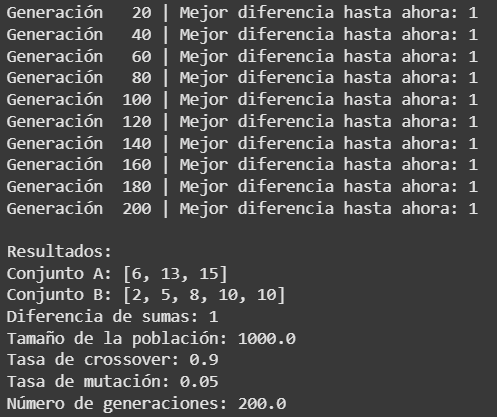

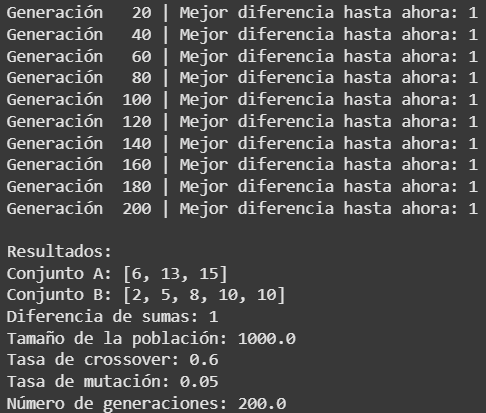

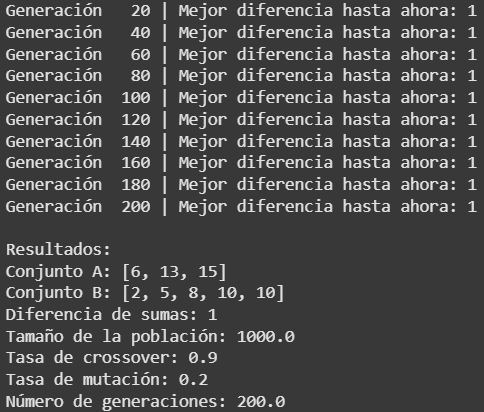

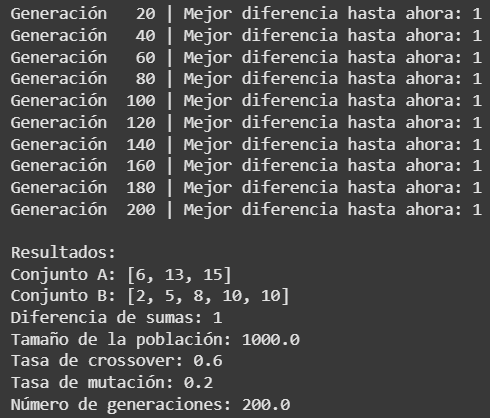

In [ ]:
from IPython.display import Image, display

# Mostrar cada imagen
display(Image(filename="ejemploa.png", width=300))
display(Image(filename="ejemplob.png", width=300))
display(Image(filename="ejemploc.png", width=300))
display(Image(filename="ejemplod.png", width=300))


#Análisis de resultados

Una tasa de cruce alta promueve la exploración, combinando soluciones existentes de forma intensiva para crear nuevas posibilidades y evitar que el algoritmo se estanque. Por el contrario, una tasa baja favorece la explotación, preservando las características de las mejores soluciones ya encontradas.

Por su parte, una tasa de mutación alta introduce diversidad genética, lo que es clave para escapar de soluciones subóptimas. Sin embargo, si es demasiado alta, puede impedir que el algoritmo converja al destruir soluciones prometedoras. Una tasa baja permite un ajuste fino de las buenas soluciones. El objetivo es encontrar un equilibrio entre explorar nuevas áreas de búsqueda y refinar los mejores resultados hallados.

#Conclusiones



Como nos fue posible observar a lo largo de las corridas, consideramos que los algoritmos de evolución genética son altamente efectivos para lograr este tipo de series de tareas. La simbiosis y significación recíproca que hacen con el mundo biológico y externo que conocemos les permite un nivel de abstracción que se presenta como un reflejo recíproco y excelso de las cosas como las conocemos, de la vida y sus procesos, de la evolución y los rasgos que confeccionan con su bisturí la información que solapa las especies o influencia los pensamientos de quienes escriben. Es a través de la réplica de estos procesos que les comprendemos a prpofundidad, y es a través de comprenderlos, afinarlos y convertir sus procesos en aspectos con los que podamos pensar así como ellos nos permiten pensar, que se logra crear una naturalidad abstracta muy apta para resolver una miríada de problemas a lo largo de una diversas cantidad y ramas de estudios. De estamanera, refinamos, recombinamos y abstraermos la ontología del ser, la reproducción, la continuación y todos los problemas filosóficos que trae consigo esta algoritmización mecánica de procesos. Es a través de estos que conocemos, comprendemos y nosotros así como el programa, también nos editamos, nos reconocemos y así somos. Es decir, que a través de esta modelación fuimos capaces de entender, por lo menos, un poco más la epistemología de nuestra reproducción y en el proceso nos dan indicios para crear y deshacer en armonía con estos fenómenos incognoscibles, pero aún excelsos.